# $(SASA) Regular$

$loss = \alpha \times mse(\hat{\theta_i^a}, \hat{\theta_j^a}) + \beta \times (1-mse(\hat{\theta_i^a}, \hat{\theta_k^b})) + \gamma \times mse(\hat{s_{i+2}^a}, y) + \lambda(\hat{\theta_i^a}^2 + \hat{\theta_k^b}^2 + \hat{\theta_j^a}^2)$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Regularized_Reference_Loss_Normalized
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2359,23,93,"(0.2048148528652186, 0.3945260327599418)","(0.046, -0.199, 0.023, 0.458)",0,1.0,"(0.042, -0.399, 0.032, 0.87)",1.0,1.0,"(0.034, -0.2, 0.049, 0.482)"
2245,10,88,"(0.4162542062822604, 0.4644156025476709)","(-0.03, 0.014, 0.04, 0.155)",0,1.0,"(-0.029, -0.187, 0.043, 0.582)",0.0,1.0,"(-0.033, -0.388, 0.055, 1.01)"
2474,8,97,"(0.1358594884350926, 0.7069625486901497)","(-0.007, -0.39, 0.036, 0.489)",0,1.0,"(-0.014, -0.582, 0.046, 0.709)",0.0,1.0,"(-0.026, -0.774, 0.06, 0.932)"
1939,20,77,"(0.1064004661572971, 0.3173964772630564)","(-0.012, -0.367, -0.049, 0.159)",1,1.0,"(-0.02, -0.163, -0.046, -0.328)",1.0,1.0,"(-0.023, 0.041, -0.053, -0.814)"
444,9,18,"(0.3051056444765603, 0.3905400892149759)","(0.043, 0.237, -0.152, -0.797)",0,1.0,"(0.048, 0.039, -0.168, -0.435)",0.0,1.0,"(0.049, -0.158, -0.176, -0.082)"
...,...,...,...,...,...,...,...,...,...,...
693,3,24,"(0.381115827959413, 0.5947037963670837)","(-0.021, 0.186, 0.014, -0.3)",0,1.0,"(-0.018, -0.01, 0.008, 0.015)",0.0,1.0,"(-0.018, -0.206, 0.008, 0.327)"
181,65,6,"(0.2451557536988955, 1.3793967951445396)","(-0.183, -0.938, -0.047, 0.269)",1,1.0,"(-0.202, -0.75, -0.042, 0.144)",1.0,1.0,"(-0.217, -0.563, -0.039, 0.02)"
193,77,6,"(0.2451557536988955, 1.3793967951445396)","(-0.34, -0.56, -0.032, -0.028)",1,1.0,"(-0.352, -0.373, -0.033, -0.151)",0.0,1.0,"(-0.359, -0.56, -0.036, -0.036)"
1413,28,57,"(0.4858968354133477, 0.4002511587990111)","(-0.097, -0.385, 0.118, 0.391)",0,1.0,"(-0.104, -0.593, 0.126, 0.958)",1.0,1.0,"(-0.116, -0.391, 0.145, 0.525)"


In [3]:
model = Model(transition_criterion_clss=Regularized_Reference_Loss_Normalized)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, alpha=loss_param, beta=loss_param, lambda_=loss_param)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_positive,mse_negative,mse_s,regularize,transition,reward
0,0,"[0.19092042744159698, 1.093295693397522]","[0.19100865721702576, 1.0932036638259888]","[0.010416986420750618, 0.018984220921993256, 0...",0.803370,0.464014,0.410628
1,1,"[0.1878184974193573, 1.0988941192626953]","[0.18790753185749054, 1.0987205505371094]","[0.010278006084263325, 0.018887676298618317, 0...",0.803473,0.445687,0.406114
2,2,"[0.18476080894470215, 1.1045396327972412]","[0.18484880030155182, 1.1042821407318115]","[0.010141479782760143, 0.01879058964550495, 0....",0.803609,0.427843,0.401656
3,3,"[0.18175293505191803, 1.1102288961410522]","[0.18183885514736176, 1.1098839044570923]","[0.010007052682340145, 0.018691176548600197, 0...",0.803777,0.410475,0.397256
4,4,"[0.1787942498922348, 1.1159721612930298]","[0.17887835204601288, 1.1155329942703247]","[0.009874258190393448, 0.018589628860354424, 0...",0.803979,0.393574,0.392915


In [4]:
data.training_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__
2359,23,93,"(0.2048148528652186, 0.3945260327599418)","(0.046, -0.199, 0.023, 0.458)",0,1.0,"(0.042, -0.399, 0.032, 0.87)",1.0,1.0,"(0.034, -0.2, 0.049, 0.482)"
2245,10,88,"(0.4162542062822604, 0.4644156025476709)","(-0.03, 0.014, 0.04, 0.155)",0,1.0,"(-0.029, -0.187, 0.043, 0.582)",0.0,1.0,"(-0.033, -0.388, 0.055, 1.01)"
2474,8,97,"(0.1358594884350926, 0.7069625486901497)","(-0.007, -0.39, 0.036, 0.489)",0,1.0,"(-0.014, -0.582, 0.046, 0.709)",0.0,1.0,"(-0.026, -0.774, 0.06, 0.932)"
1939,20,77,"(0.1064004661572971, 0.3173964772630564)","(-0.012, -0.367, -0.049, 0.159)",1,1.0,"(-0.02, -0.163, -0.046, -0.328)",1.0,1.0,"(-0.023, 0.041, -0.053, -0.814)"
444,9,18,"(0.3051056444765603, 0.3905400892149759)","(0.043, 0.237, -0.152, -0.797)",0,1.0,"(0.048, 0.039, -0.168, -0.435)",0.0,1.0,"(0.049, -0.158, -0.176, -0.082)"


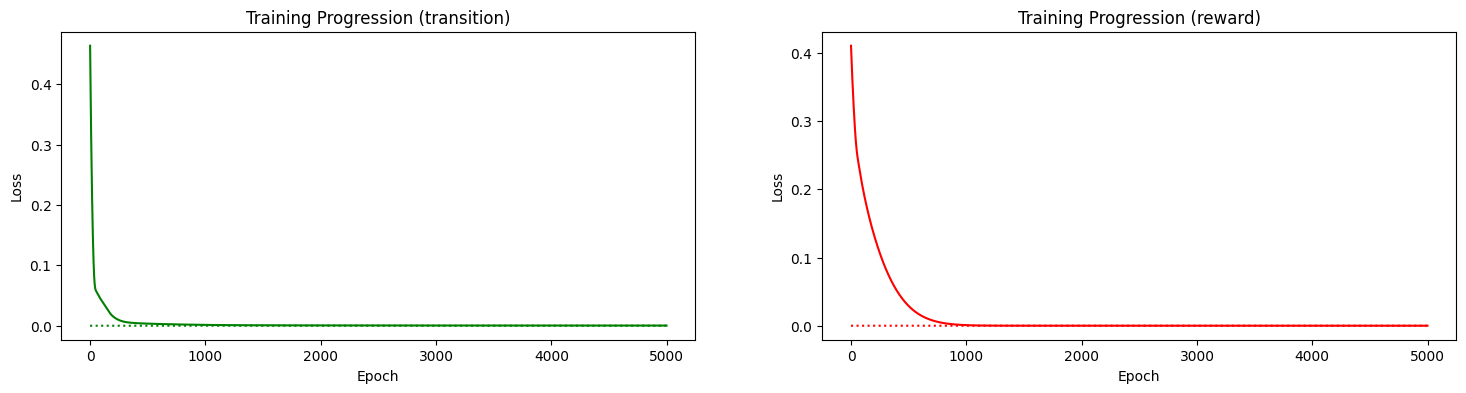

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

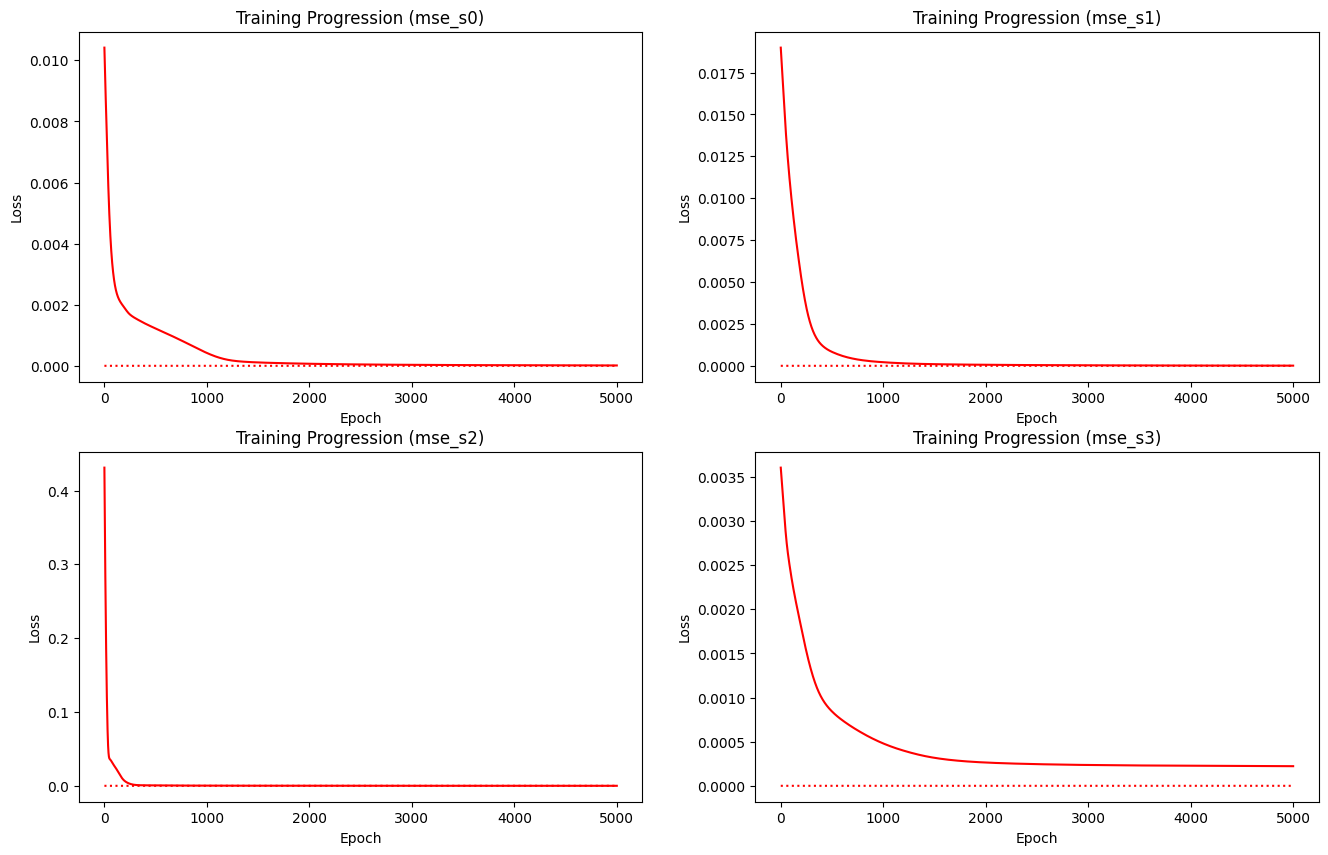

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

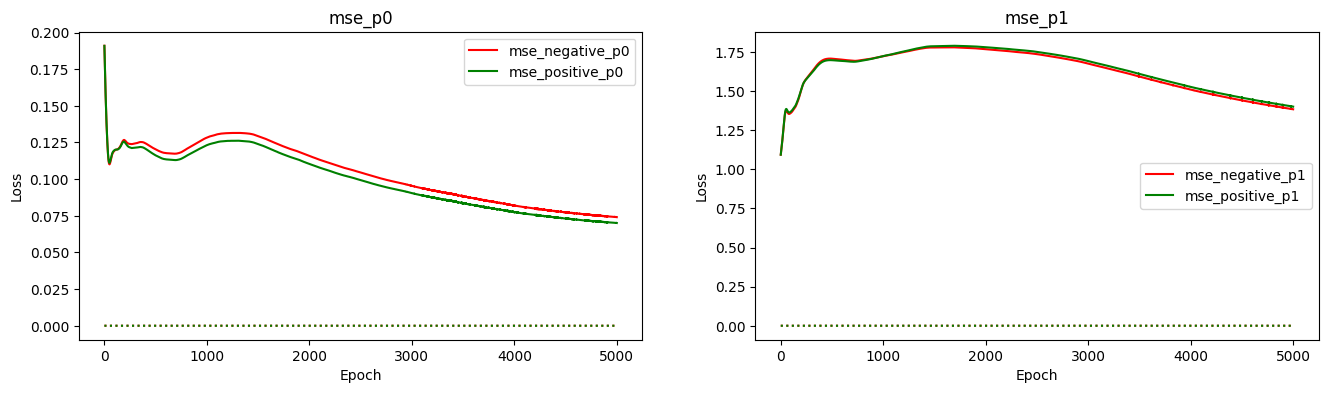

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
    'mse_negative': ['mse_negative_p0', 'mse_negative_p1'],
    'mse_positive': ['mse_positive_p0', 'mse_positive_p1'],
}

df = get_data_expanded(train_data, expansions)

for i,(neg, pos) in enumerate(zip(expansions['mse_negative'], expansions['mse_positive'])):
    data.plot_training_loss(axs[i], df[neg], 'r')
    data.plot_training_loss(axs[i], df[pos], 'g')
    axs[i].set_title(f'mse_p{i}')
    axs[i].legend()

plt.show()

## Params

In [8]:
import pandas as pd

training_params = pd.DataFrame(y.numpy(), columns=model.targets_lables)

expansions = {
    'p': ['p0', 'p1']
}
df_trainning = get_data_expanded(data.training_data.loc[(data.training_data.epoch==499)], expansions)

df_trainning_p = pd.DataFrame([], columns=['epoch', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1', 'p0', 'p1'])
for epoch in df_trainning.epoch.unique():
    copy = df_trainning[df_trainning.epoch == epoch].copy()[['epoch', 'p0', 'p1']].reset_index(drop=True)
    copy[['sample', 'positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']] = training_params.copy()[['positive_p0', 'positive_p1', 'negative_p0', 'negative_p1']].reset_index()
    df_trainning_p = pd.concat([df_trainning_p, copy])

df_trainning_p.head()

/tmp/ipykernel_7536/580248604.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_trainning_p = pd.concat([df_trainning_p, copy])


,epoch,positive_p0,positive_p1,negative_p0,negative_p1,p0,p1,sample
0,499,0.204815,0.394526,0.319718,0.810802,0.063453,-0.633694,0.0
1,499,0.416254,0.464416,0.064292,1.239005,0.014785,-0.528773,1.0
2,499,0.135859,0.706963,0.124287,0.298499,0.029269,-0.589033,2.0
3,499,0.106400,0.317396,0.418223,0.086339,-0.015114,-0.541982,3.0
4,499,0.305106,0.390540,0.177104,0.830052,0.166458,-0.688274,4.0


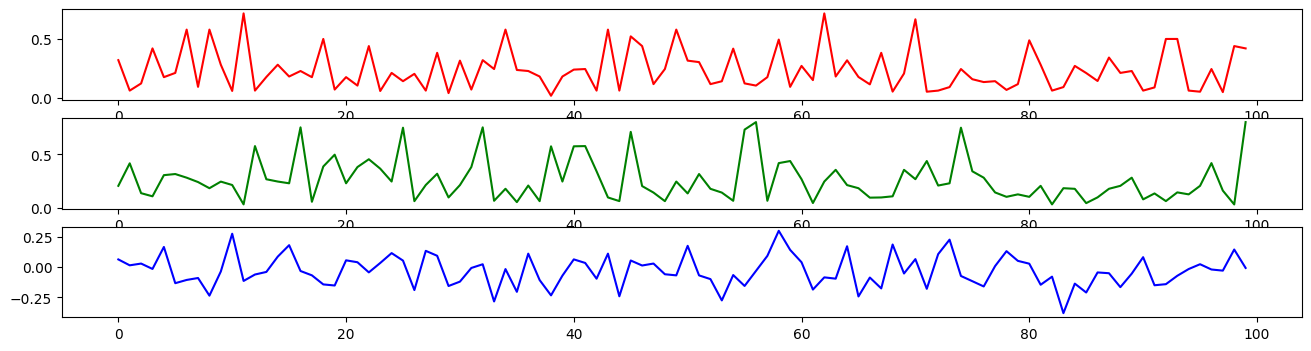

In [9]:
fig, axs = plt.subplots(3, 1, figsize=(16, 4))

axs[0].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['negative_p0'], color='r', label='negative')
axs[1].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['positive_p0'], color='g', label='positve')
axs[2].plot(df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]['p0'], color='b', label='estimative')

plt.show()

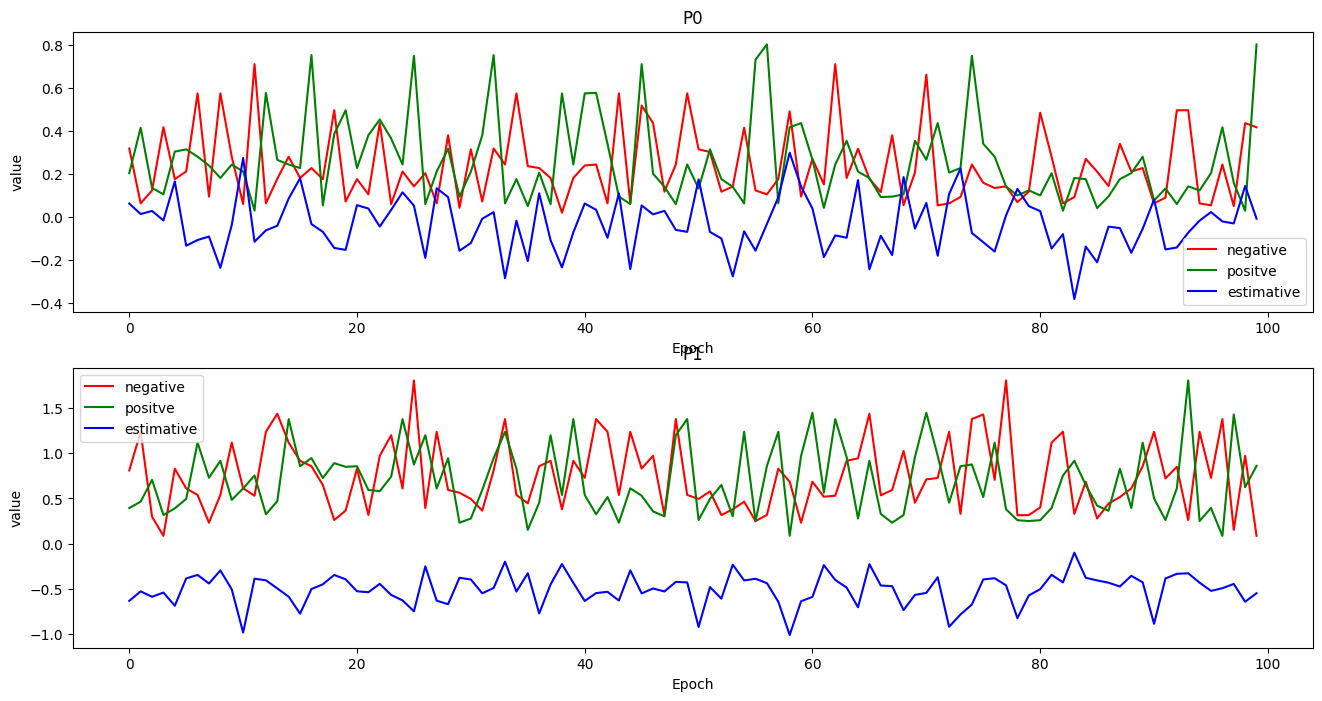

In [10]:
fig, axs = plt.subplots(2,1, figsize=(16, 8))

# df = df_trainning_p.groupby('epoch').mean()
# df = df_trainning_p.groupby('sample').mean()
df = df_trainning_p.loc[(df_trainning_p.epoch==499) & (df_trainning_p['sample']<100)]

axs[0].plot(df['negative_p0'], color='r', label='negative')
axs[0].plot(df['positive_p0'], color='g', label='positve')
axs[0].plot(df['p0'], color='b', label='estimative')

axs[0].set_ylabel('value')
axs[0].set_xlabel('Epoch')
axs[0].set_title(f'P0')
axs[0].legend()

axs[1].plot(df['negative_p1'], color='r', label='negative')
axs[1].plot(df['positive_p1'], color='g', label='positve')
axs[1].plot(df['p1'], color='b', label='estimative')

axs[1].set_ylabel('value')
axs[1].set_xlabel('Epoch')
axs[1].set_title(f'P1')
axs[1].legend()

plt.show()

## Best and worst episodes

In [11]:
data.evaluate_model(model, path='../training_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.0730412080386606, 0.3656961190344961)","(0.011, 0.034, 0.014, 0.009)",0,1.0,"(0.012, -0.165, 0.014, 0.407)",0.0,1.0,"(0.009, -0.365, 0.023, 0.806)",...,0.000,0.002,0.001,0.066,0.0,0.403414,0.419411,0.501199,0.57732,0.069
1,1,0,"(0.0730412080386606, 0.3656961190344961)","(0.012, -0.165, 0.014, 0.407)",0,1.0,"(0.009, -0.365, 0.023, 0.806)",0.0,1.0,"(0.001, -0.565, 0.039, 1.207)",...,0.002,0.005,0.000,0.054,0.0,0.404246,0.419934,0.498801,0.57660,0.061
2,2,0,"(0.0730412080386606, 0.3656961190344961)","(0.009, -0.365, 0.023, 0.806)",0,1.0,"(0.001, -0.565, 0.039, 1.207)",0.0,1.0,"(-0.01, -0.766, 0.063, 1.616)",...,0.001,0.010,0.000,0.048,0.0,0.403830,0.420805,0.498801,0.57624,0.059
3,3,0,"(0.0730412080386606, 0.3656961190344961)","(0.001, -0.565, 0.039, 1.207)",0,1.0,"(-0.01, -0.766, 0.063, 1.616)",1.0,1.0,"(-0.025, -0.567, 0.095, 1.25)",...,0.008,0.002,0.000,0.075,0.0,0.406744,0.419411,0.498801,0.57786,0.085
4,4,0,"(0.0730412080386606, 0.3656961190344961)","(-0.01, -0.766, 0.063, 1.616)",1,1.0,"(-0.025, -0.567, 0.095, 1.25)",1.0,1.0,"(-0.036, -0.369, 0.12, 0.9)",...,0.003,0.001,0.000,0.072,0.0,0.404663,0.419237,0.498801,0.57768,0.076


In [12]:
rmse = results[['episode', 'rse_s0', 'rse_s1', 'rse_s2', 'rse_s3']].groupby('episode').mean().reset_index()
rmse['rmse'] = rmse.rse_s0 + rmse.rse_s1 + rmse.rse_s2 + rmse.rse_s3
rmse_sorted = rmse.sort_values(by='rmse')
epis = rmse.shape[0]

best_episodes = rmse_sorted.head(3).episode.values
worst_episodes = rmse_sorted.tail(3).episode.values
print(f'{best_episodes=}', f'{worst_episodes=}')

best_episodes=array([73, 96, 24]) worst_episodes=array([17, 20, 32])


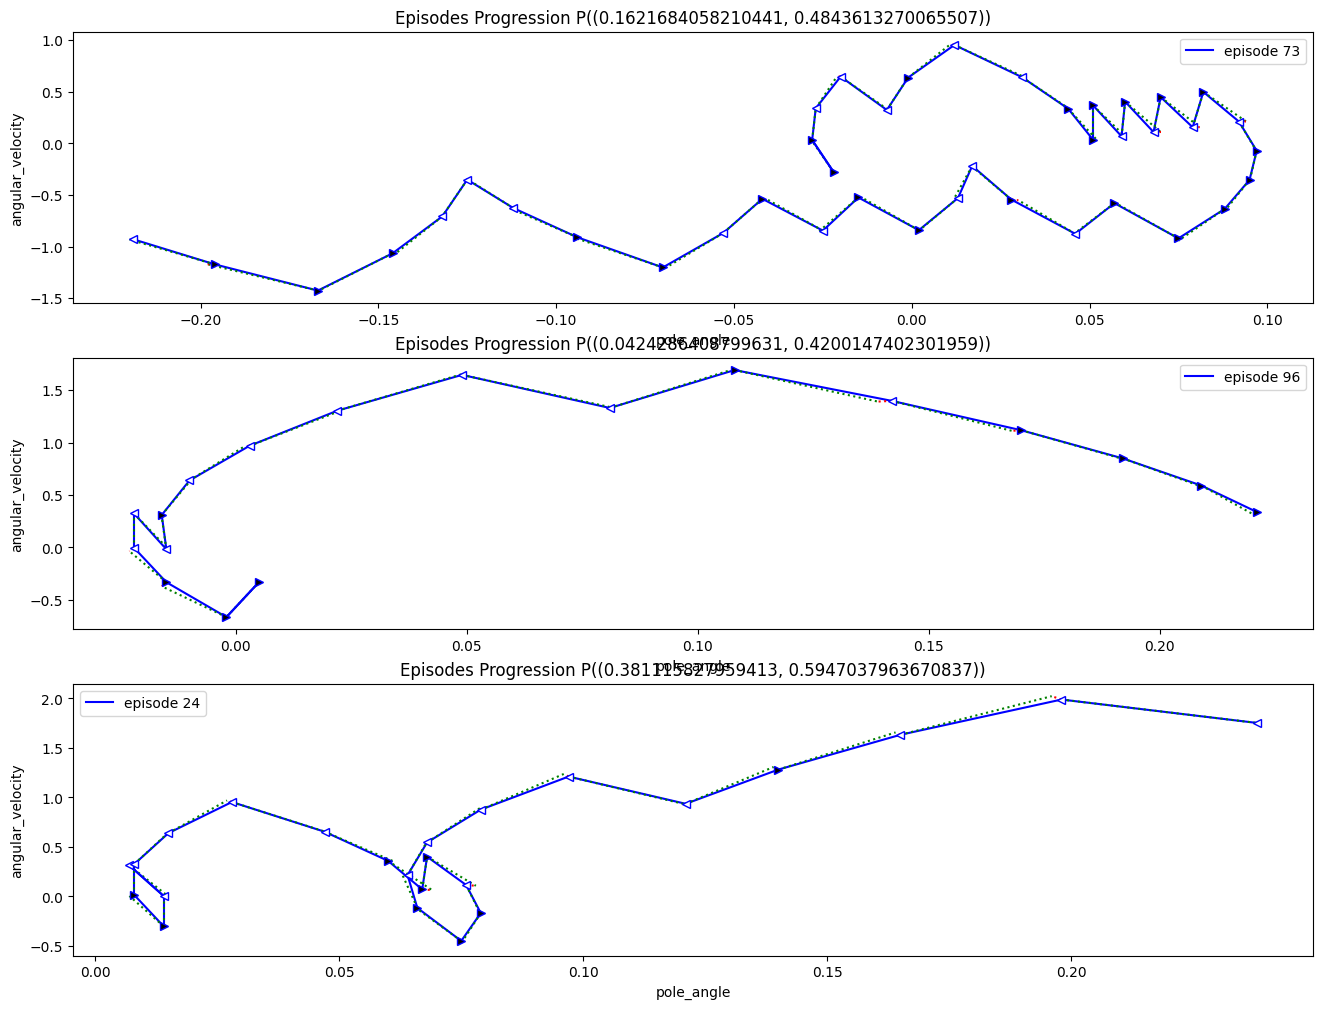

In [13]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(best_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

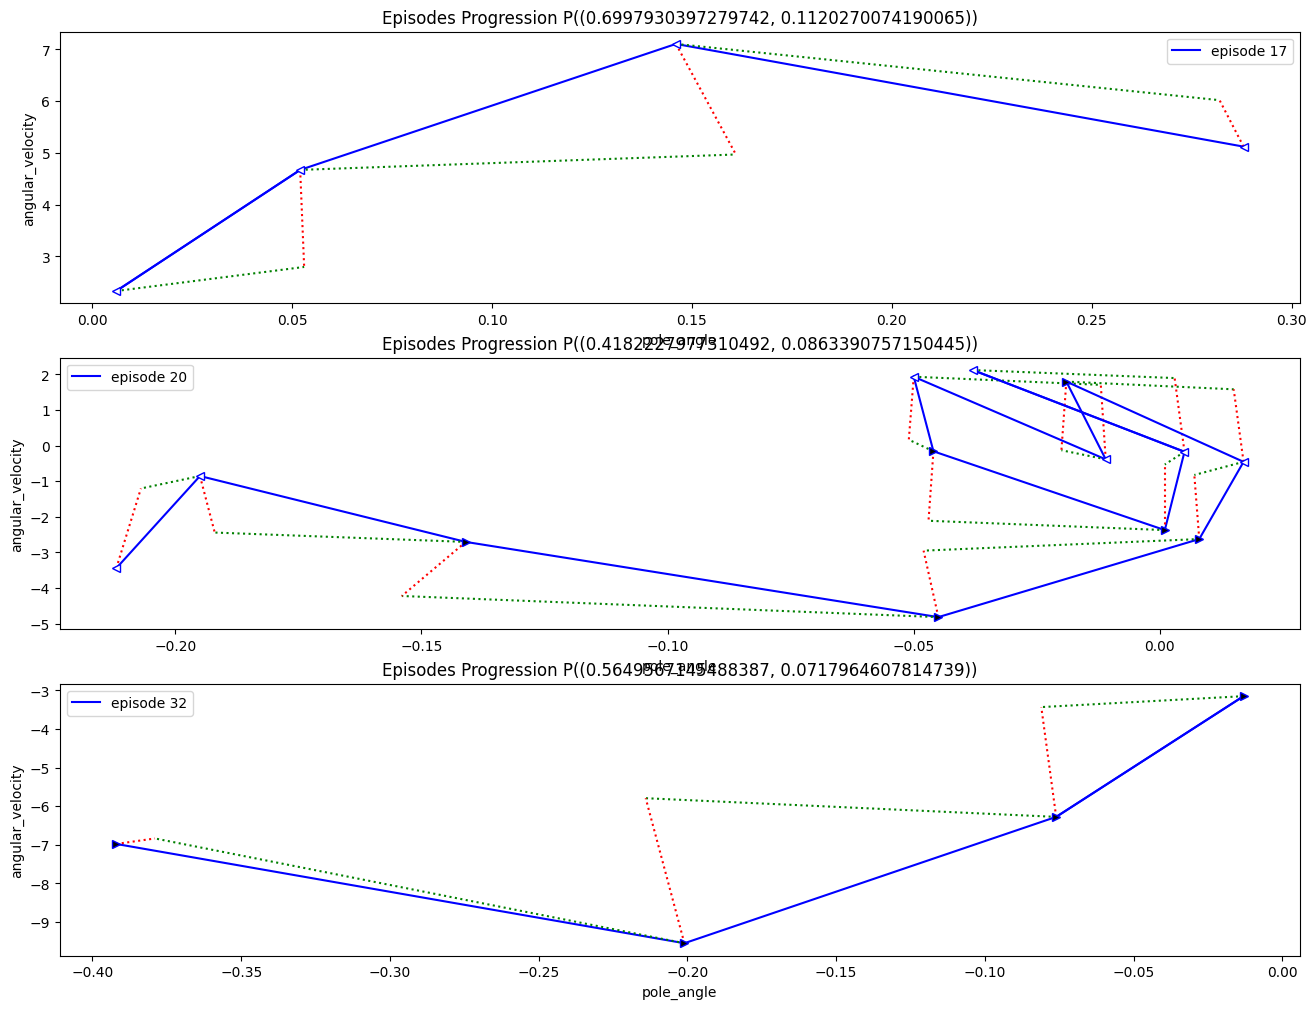

In [14]:
fig, axs = plt.subplots(3, 1, figsize=(16, 12))

for i, epi in enumerate(worst_episodes):
    data.plot_episode_progression_with_predictions(axs[i], epi)
plt.show()

## Kmeans

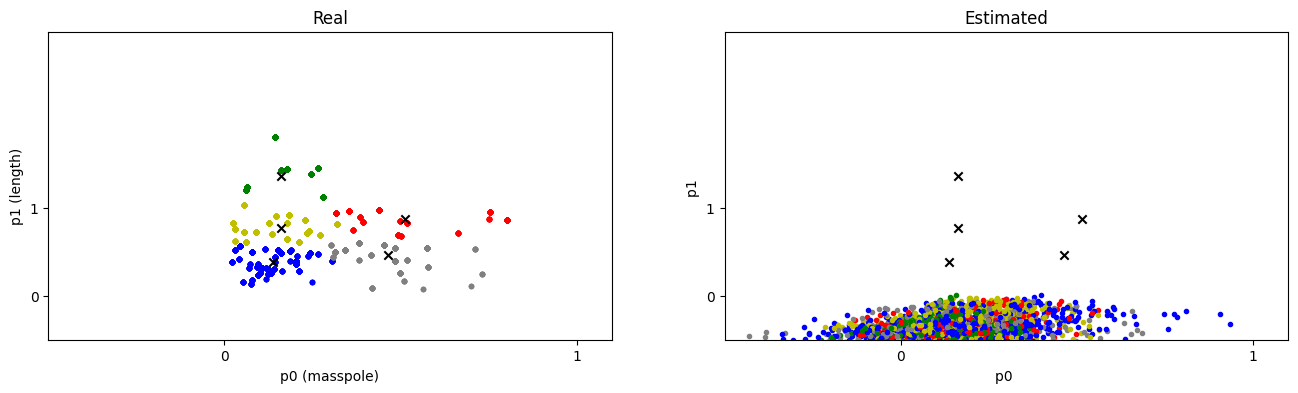

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Evaluation

In [16]:
data.evaluate_model(model, path='../testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.009,0.026,0.003,0.873,0.0,0.555438,0.532448,0.508393,0.509369,0.911
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.017,0.026,0.002,0.957,0.0,0.563886,0.532448,0.505995,0.516557,1.002
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.003,0.058,0.002,0.978,0.0,0.549102,0.540315,0.505995,0.518354,1.041
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.009,0.038,0.004,0.883,0.0,0.555438,0.535398,0.510791,0.510225,0.934
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.006,0.060,0.003,1.024,0.0,0.552270,0.540806,0.508393,0.522290,1.093


In [17]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.004078,0.011921,0.001194,0.172069,0.0,0.550240,0.528988,0.504063,0.449394,0.189262
std,0.004711,0.012530,0.001489,0.211067,0.0,0.004975,0.003080,0.003571,0.018060,0.220157
min,0.000000,0.000000,0.000000,0.000000,0.0,0.545935,0.526057,0.501199,0.434671,0.004000
25%,0.001000,0.004000,0.000000,0.064000,0.0,0.546990,0.527040,0.501199,0.440147,0.077000
50%,0.003000,0.009000,0.001000,0.117000,0.0,0.549102,0.528269,0.503597,0.444682,0.131000
75%,0.005000,0.016000,0.002000,0.193000,0.0,0.551214,0.529990,0.505995,0.451185,0.209500
max,0.060000,0.133000,0.017000,2.129000,0.0,0.609293,0.558751,0.541966,0.616839,2.250000


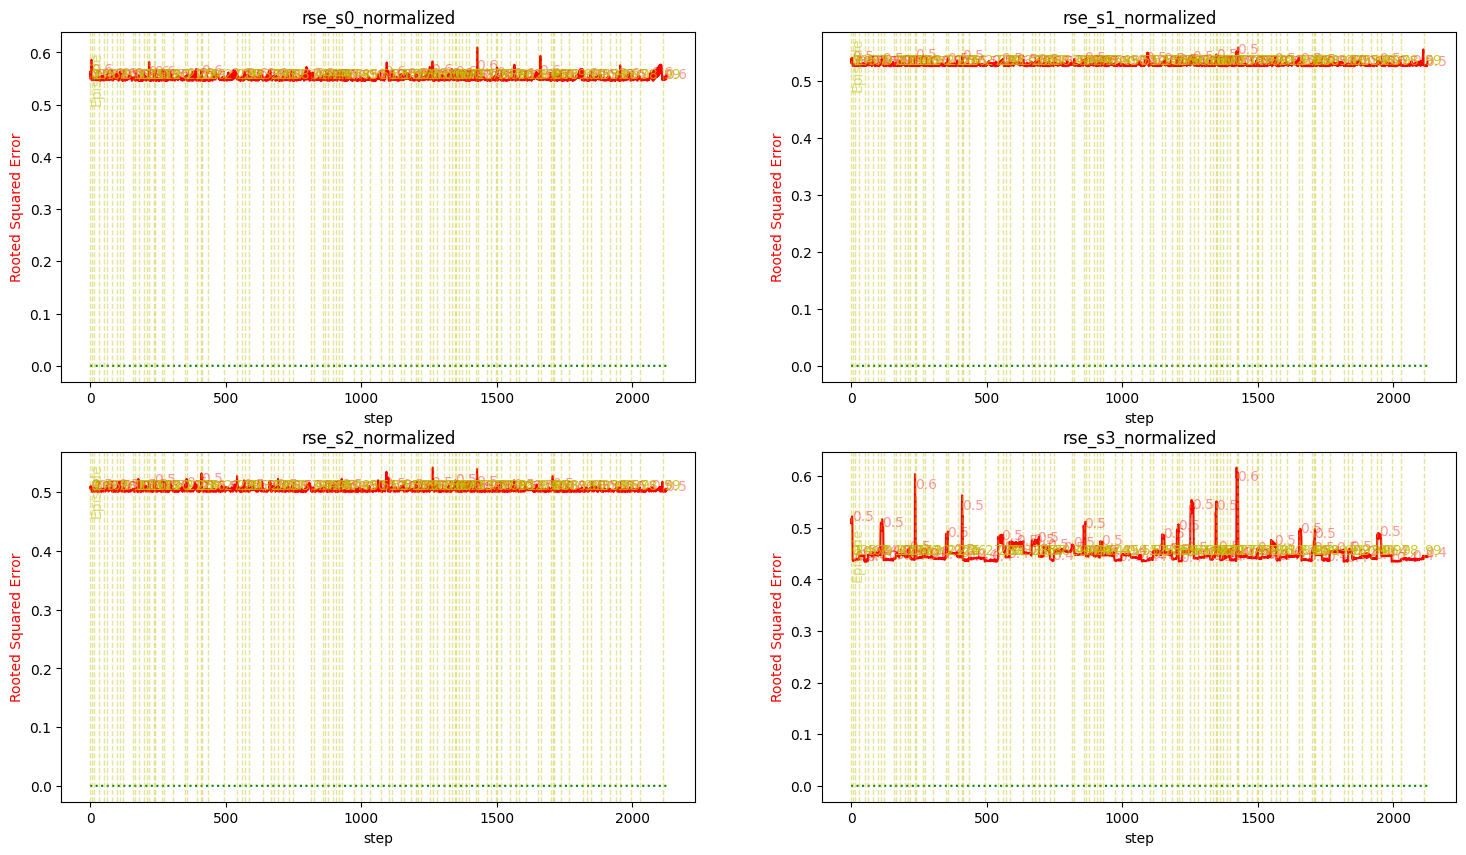

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

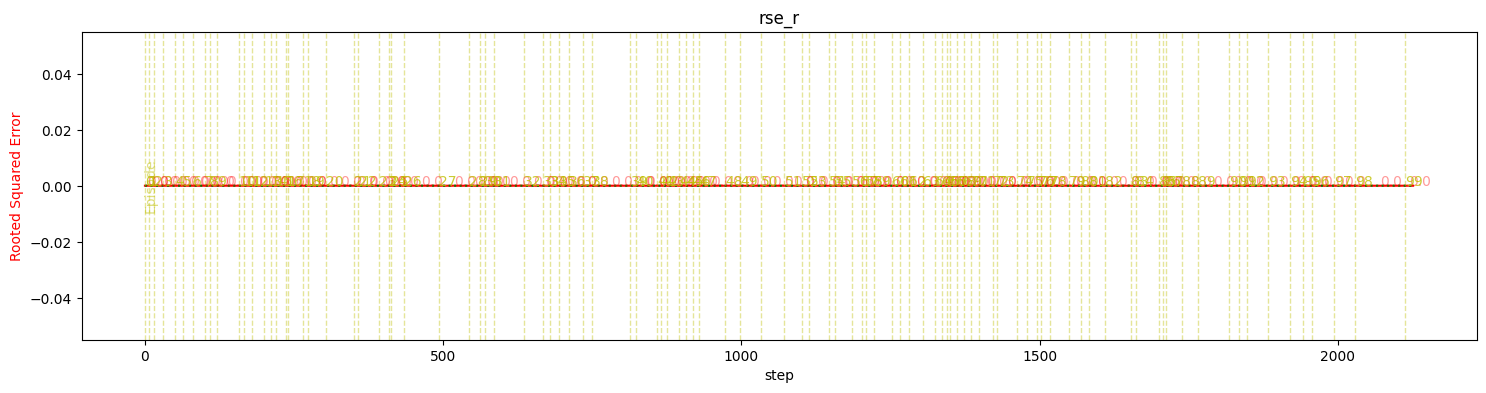

In [19]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/gui/Área de Trabalho/rlalgs/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gui/Área de Trabalho/rlalgs/.venv/lib/pyt

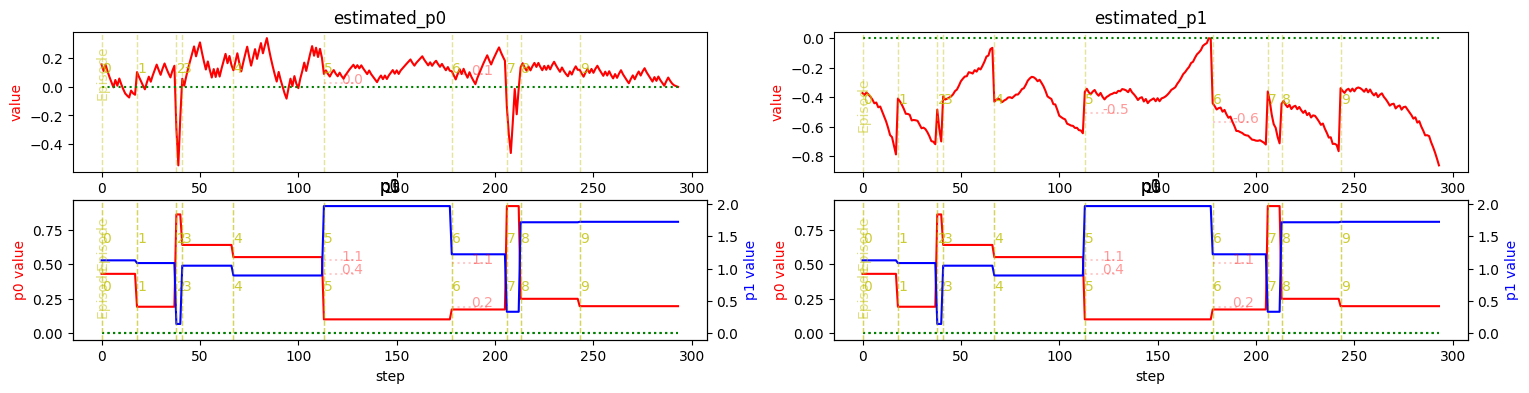

In [20]:
import numpy as np

n = 10

df = results[['episode', 'estimated_p0', 'estimated_p1', 'p0', 'p1']].groupby("episode").mean().reset_index()
df['dist_p0'] = np.sqrt(np.pow(df['estimated_p0']-df['p0'], 2))
df['dist_p1'] = np.sqrt(np.pow(df['estimated_p1']-df['p1'], 2))
df['dist'] = df['dist_p0'] + df['dist_p1']
worst = df.loc[df.rank(ascending=False)['dist']<=n].episode
df = results[results['episode'].isin(worst)].reset_index(drop=True)

fig, axs = plt.subplots(2, 2, figsize=(18,4))
data.plot_value_through_episodes(axs[0][0], df, 'estimated_p0', y_label='value')
data.plot_value_through_episodes(axs[0][1], df, 'estimated_p1', y_label='value')

data.plot_value_through_episodes(axs[1][0], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][0].twinx(), df, 'p1', y_label='p1 value', color='b')

data.plot_value_through_episodes(axs[1][1], df, 'p0', y_label='p0 value')
data.plot_value_through_episodes(axs[1][1].twinx(), df, 'p1', y_label='p1 value', color='b')

plt.show()

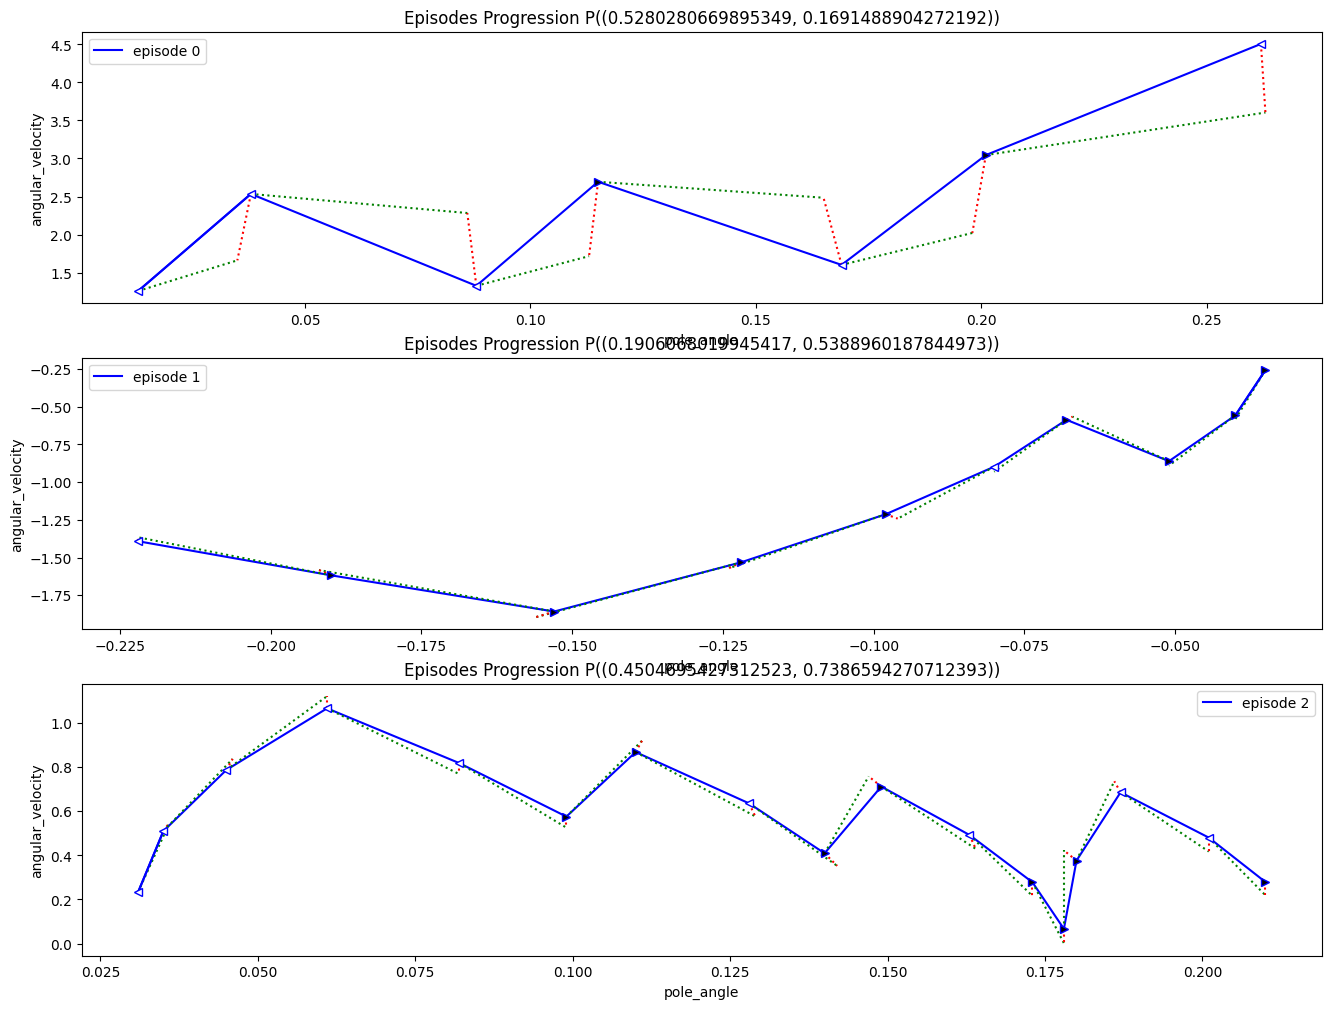

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()

## Cluster

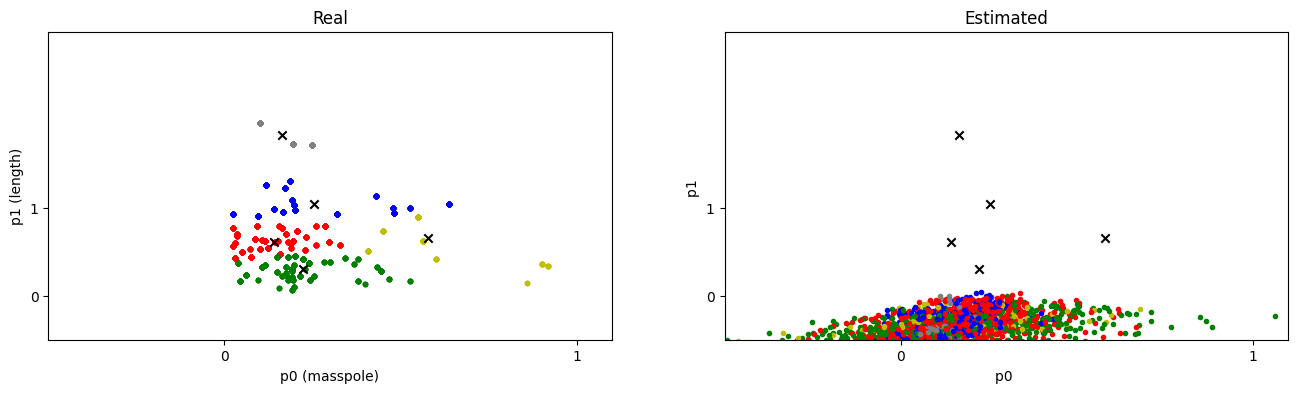

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4))
data.plot_clusters(axs, results)
plt.show()

# Save

In [23]:
import pickle

exp = {
    "data": data,
    "model": model 
}

nome_do_arquivo = 'regular_normilized.pkl'
with open(nome_do_arquivo, 'wb') as arquivo:
    pickle.dump(exp, arquivo)